# Finding musical borrowing with EMMSAP

:This was a quick AI-generated demo of searching with EMMSAP -- it's not the best way to do it.

**EMMSAP** (Electronic Medieval Music Score Archive Project) indexes every melodic line
of ~3,600 fourteenth‑ and fifteenth‑century pieces and pre‑computes a *similarity score*
(0–10000) between every pair of short melodic segments, so you can ask:
**“where else does this music turn up?”** — even across pieces with completely different
titles and composers.

This notebook runs live searches and draws the answers as music with
[music21](https://www.music21.org/)’s `.show()`, right inside the notebook.

In [5]:
# --- Setup: connect the notebook to the EMMSAP database (run Jupyter from the repo root) ---
import os, sys
sys.path.insert(0, os.path.abspath('..'))            # so `import emmsap2` works
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = 'true'   # Jupyter runs an event loop; allow sync ORM calls

try:                                               # production installs use mysqlclient…
    import MySQLdb                                  # noqa: F401
except ImportError:                                # …otherwise fall back to pure-python PyMySQL
    import pymysql
    pymysql.version_info = (2, 2, 8, 'final', 0); pymysql.__version__ = '2.2.8'
    pymysql.install_as_MySQLdb()

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'emmsap2.settings')
import django; django.setup()

import pandas as pd
from django.db import transaction
from django.db.models import Max, Count
from emmsap2.models import Piece, Segment, Ratio, SkipGroup, SkipPiece
from emmsap2.similarity_ratio import SimilaritySearcher

print(f'Connected ✔  {Piece.objects.count():,} pieces indexed, '
      f'{Ratio.objects.filter(encoding_type="dia_rhy").count():,} melodic matches pre-computed')

Connected ✔  3,655 pieces indexed, 77,822 melodic matches pre-computed


## Two small search helpers

`search_matches()` runs the **same query the `SimilaritySearcher` uses** (diatonic‑ +
rhythm‑encoded segments, ranked by score, known duplicates suppressed) and rolls the hits
up per piece.  `render_match()` draws the strongest shared passage between two pieces —
the two excerpts stacked, with the similarity score labelled between them — so we can
actually *see* and *hear* it.

In [6]:
def _resolve(piece):
    if isinstance(piece, (str, int)):
        return Piece.objects.get(**({'pk': piece} if isinstance(piece, int) else {'filename': piece}))
    return piece

def search_matches(piece: str|int|Piece, *, min_threshold=8000, segment_type='dia_rhy',
                   ignore_known_skips=True, limit=10):
    """Where else EMMSAP finds this piece's melodies — one row per matched piece."""
    piece = _resolve(piece)
    skips = piece.skip_piece_ids() if ignore_known_skips else set()
    rows = (Ratio.objects
            .filter(encoding_type=segment_type, segment1__piece_id=piece.id, ratio__gte=min_threshold)
            .exclude(segment2__piece_id=piece.id)
            .exclude(segment2__piece_id__in=skips)
            .values('segment2__piece__filename')
            .annotate(best_score=Max('ratio'), passages=Count('id'))
            .order_by('-best_score')[:limit])
    tidy = lambda fn: fn.replace('.xml', '').replace('.mxl', '')
    return pd.DataFrame([{
        'best score': r['best_score'],
        'matching passages': r['passages'],
        'also appears in': tidy(r['segment2__piece__filename']),
    } for r in rows])

def render_match(piece_a, piece_b, segment_type='dia_rhy'):
    """Draw the highest-scoring shared passage between two pieces. Returns a music21 stream."""
    a, b = _resolve(piece_a), _resolve(piece_b)
    qs = (Ratio.objects.select_related('segment1', 'segment2', 'segment2__piece')
          .filter(encoding_type=segment_type, segment1__piece_id=a.id, segment2__piece_id=b.id)
          .order_by('-ratio'))
    for r in qs:
        try:
            return r.stream()          # build the combined excerpt once
        except Exception:
            continue                   # skip segments with awkward measure ranges
    return None

## 1 · Ciconia quotes Philipoctus

**Johannes Ciconia**’s virelai *Sus une fontayne* famously weaves in melodic
quotations of works by **Philipoctus de Caserta**, including his ballade *En remirant* — a different piece, by a
different composer.  Ask EMMSAP where *Sus une fontayne*’s melodies recur, and it points
straight at *En remirant*.

In [16]:
search_matches('PMFC_24_45-Sus_une_fontayne.xml')

,best score,matching passages,also appears in
0,9000,5,Stoessel_Ch_057-En_remirant
1,8666,4,Stoessel_Mod_68-En_remirant


Draw the strongest shared passage.  The upper excerpt is Ciconia; the lower is
Philipoctus.  Same melodic gesture — Ciconia has re‑barred it from 9/8 into 6/8, exactly
the kind of rhythmic reworking a quotation gets:

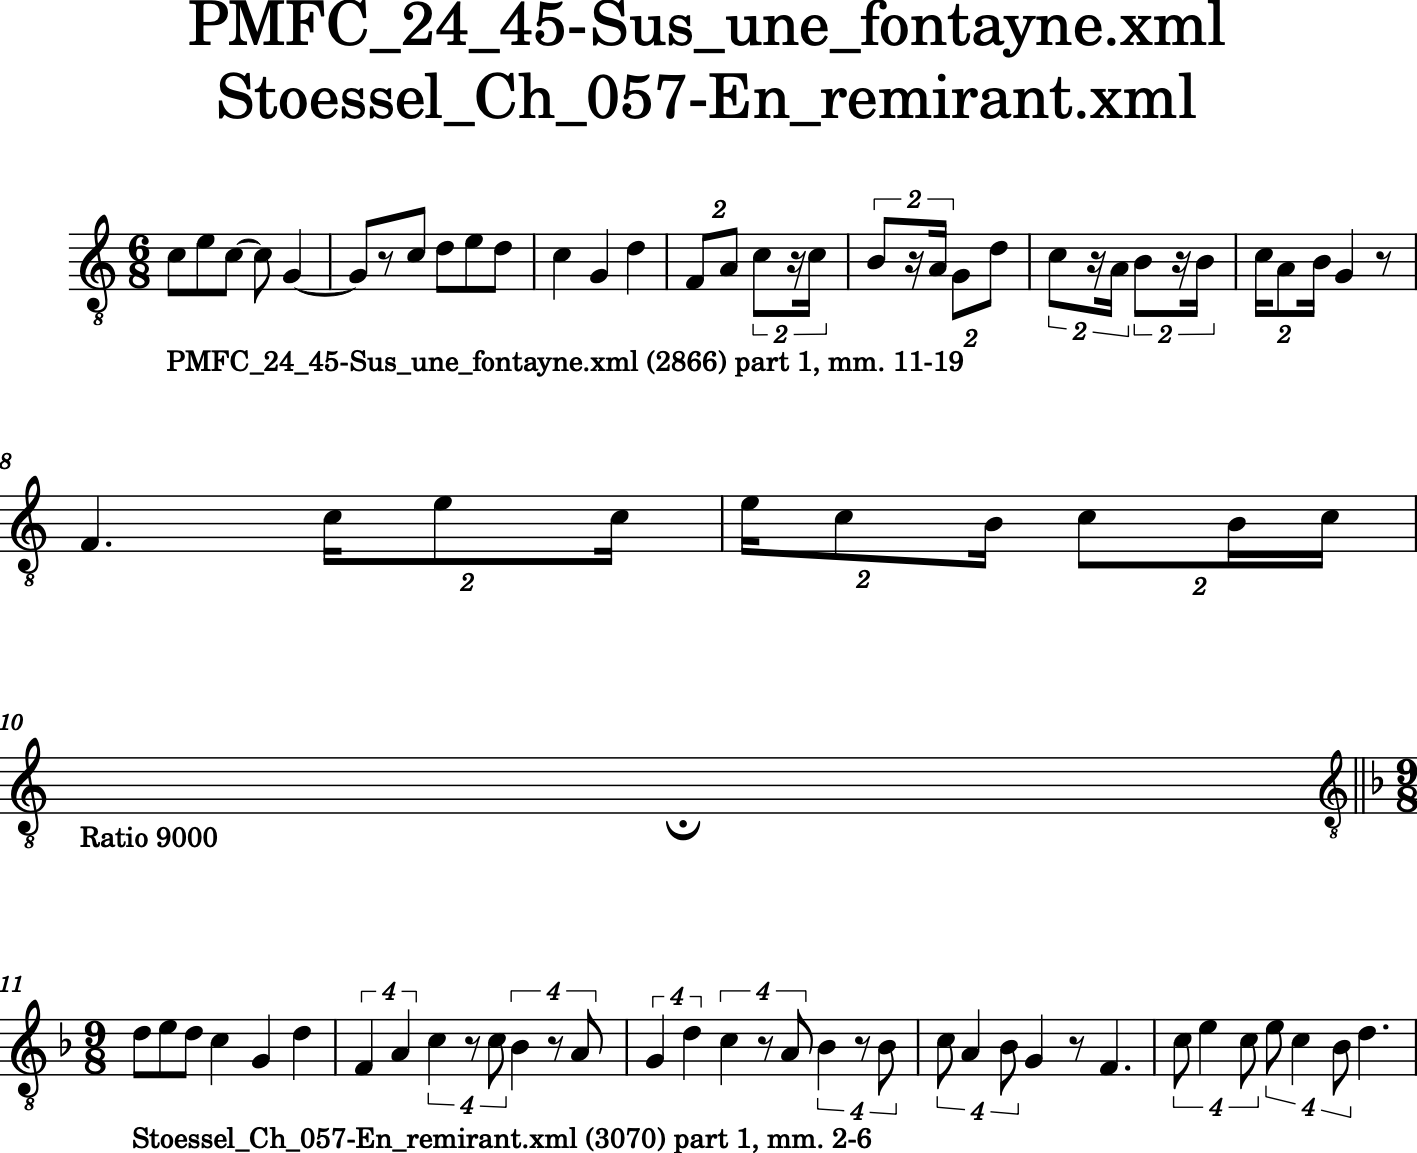

In [9]:
match = render_match('PMFC_24_45-Sus_une_fontayne.xml', 'Stoessel_Ch_057-En_remirant.xml')
match.show()          # music21 renders the notation inline

Notice that the match was made even though the two passages use different encodings for the tuplets (2:3 and 4:3) and are encoded with different time signatures.

### …and you can *hear* it

`show('midi')` embeds a player, so a search result becomes something you can listen to:

In [10]:
match.show('midi')

## 2 · One tenor, many motets

A thirteenth‑century motet is built over a borrowed scrap of plainchant — its **tenor** —
and the same tenor melody underpins many otherwise‑unrelated motets with entirely different
texts and titles.  Search the Montpellier‑Codex motet *Ja n’amerai* and EMMSAP surfaces the
whole family sharing its *In seculum* tenor — *Lautrier trouvai*, *He tres douces amouretes*,
*Se gries m’est*, and more — matching at the maximum score of 10000:

In [11]:
search_matches('mo_I_2-Ja_namerai.mxl')

,best score,matching passages,also appears in
0,10000,121,mo_V_137-Ja_namerai_autre_que_cele
1,10000,100,mo_V_73-In_seculum
2,10000,41,mo_IV_65-Si_vere_vis_adherere
3,10000,37,mo_VIII_324-Quant_se_depart
4,10000,15,mo_V_107-He_tres_douces_amouretes
5,10000,15,mo_V_118-Lautrier_trouvai_une_plesant_tousete
6,10000,12,mo_V_120-En_son_service_amourous_toute_vie_mai...
7,10000,13,mo_V_134-On_doit_fine_amor_anourer_nuit_et_jor
8,10000,15,mo_V_162-Se_gries_mest_au_cuers
9,9152,16,mo_VI_207-Ne_ma_pas_oublie


Two of these motets side by side — different pieces, different words, the *same* tenor line:

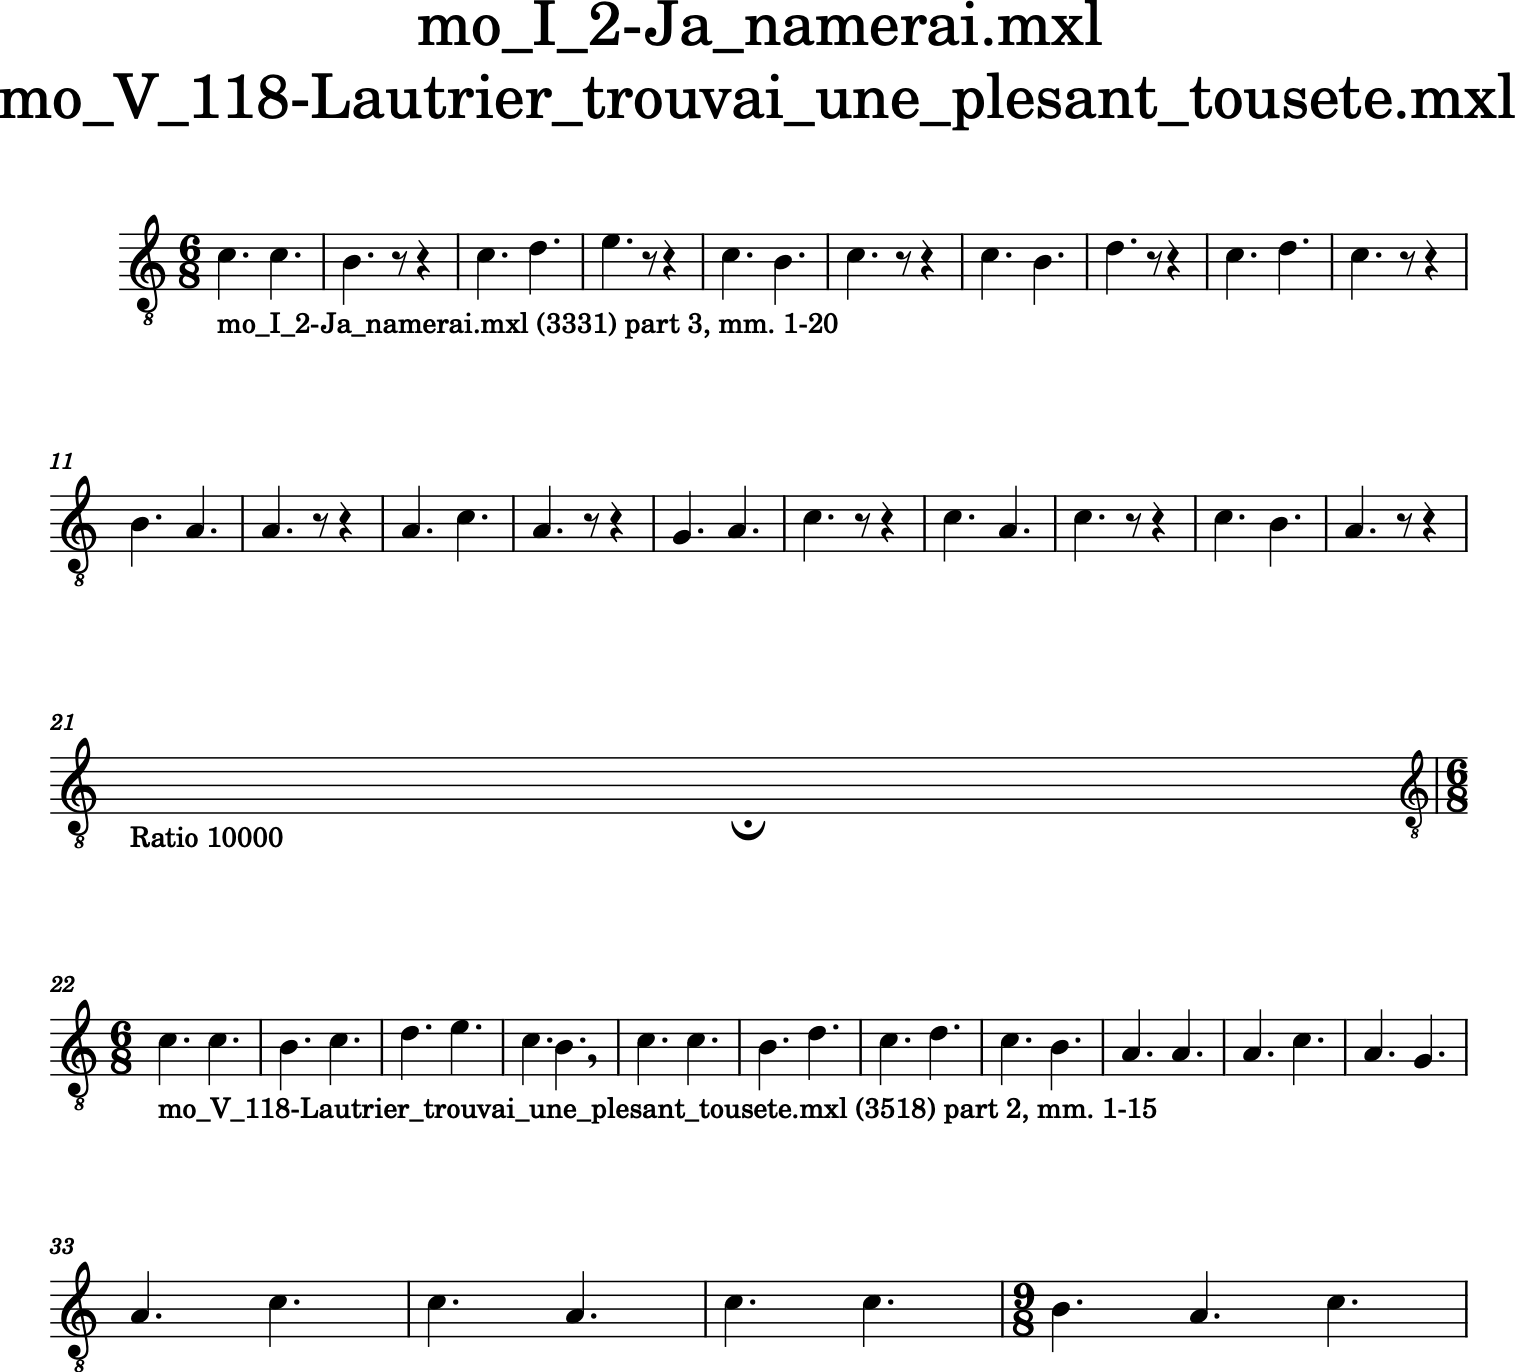

In [12]:
render_match('mo_I_2-Ja_namerai.mxl', 'mo_V_118-Lautrier_trouvai_une_plesant_tousete.mxl').show()

## 3 · The engine, and hiding the *boring* matches

`SimilaritySearcher` drives all of this.  Its knobs decide what counts as a real match —
`min_threshold`, an *anti‑noodle* penalty (stepwise wandering matches too easily), a raised
bar for tenors, and **skip groups**: sets of pieces already known to be *the same music*
(alternate transcriptions, literal duplicates).  Those aren’t discoveries, so they’re
suppressed — keeping genuine finds like the two above on top.

In [13]:
searcher = SimilaritySearcher(start_piece=3093, end_piece=3094, min_threshold=8000)
print('segment encoding   :', searcher.segment_type)
print('min similarity      :', searcher.min_threshold, '(of 10000)')
print('anti-noodle penalty :', searcher.anti_noodle_protection)
print('ignore known skips  :', searcher.ignore_known_skips)

for sg in SkipGroup.objects.all():
    print(f'\nSkip group #{sg.id} — “{sg.reason}” (same piece, two sources):')
    for sp in sg.skippiece_set.select_related('piece'):
        print(f'    • piece {sp.piece_id}: {sp.piece.filename}')

segment encoding   : dia_rhy
min similarity      : 8000 (of 10000)
anti-noodle penalty : True
ignore known skips  : True

Skip group #1 — “Plaisance” (same piece, two sources):
    • piece 3093: Stoessel_Ch_090-Playsance_or_tost.xml
    • piece 3597: Playsance_or_tout_Brussels.mxl


Because *Playsance or tost* (3093) and its Brussels copy (3597) are flagged as the same
song, a search of 3093 never mentions 3597.  Lift the filter momentarily — inside a database
transaction we always roll back, so the skip group is restored the instant the cell finishes
and **nothing is permanently changed** — and the suppressed duplicate springs to the top:

In [14]:
from IPython.display import display

print('Normally suppressed from 3093’s results:', Piece.objects.get(pk=3093).skip_piece_ids())
with transaction.atomic():
    SkipPiece.objects.filter(piece_id=3597).delete()      # temporarily lift the suppression
    display(search_matches(3093).head(4))                 # 3597 now revealed at the top
    transaction.set_rollback(True)                        # ← always undo: the skip group is put back
print('After the cell, skips for 3093 restored to:', Piece.objects.get(pk=3093).skip_piece_ids())

Normally suppressed from 3093’s results: {3597}


,best score,matching passages,also appears in
0,9333,32,Playsance_or_tout_Brussels


After the cell, skips for 3093 restored to: {3597}


---
That’s EMMSAP musical search end‑to‑end: **ask** the pre‑computed index where a melody
recurs, **see** the matches as notation, **hear** them, and lean on curated skip groups so
the real discoveries — a Ciconia quotation, a shared motet tenor — stay on top.

*In a Django shell the same search is one line —*
`SimilaritySearcher(2866, 2867, 8000).run_pieces()` *— which prints every hit and calls
`.show()` on each.*